In [16]:
from JSON_parser import get_JSON_files
import os
from tqdm import tqdm

collection = "lastfm"
base_path = "../dataset_2/"
path = base_path + collection

#Load all folders names from path do not use get_JSON_files thats only for getting the fucking data
folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    
print(len(folders), "folders found")

# Recollect all data from JSON files
dataset = []
error_folder = []

for folder in tqdm(folders):
    file_path = base_path + collection + "/" + folder + "/" + folder + "_analysis.json"
    if not os.path.exists(file_path):
        error_folder.append(folder)

print(error_folder)
print(len(error_folder))

20010 folders found


100%|██████████| 20010/20010 [00:00<00:00, 172017.85it/s]

[]
0


In [2]:
print(len(error_folder))
import json

#print how many files this id has
id = "476c900a6061eb5af263eb653d6d5861"
for id in error_folder:
    id_path = base_path + collection + "/" + id 
    if os.path.exists(id_path):
        files = [f for f in os.listdir(id_path) if os.path.isfile(os.path.join(id_path, f))]
        print(f"ID {id} has {len(files)} files.")
        print(files)
        # Read its content
        for file in files:
            with open(os.path.join(id_path, file), "r") as f:
                content = json.load(f)
                print(f"Content of {file}: {content}")

0


In [3]:
# Delete those folders in error_folder including its content 
for id in error_folder:
    id_path = base_path + collection + "/" + id
    if os.path.exists(id_path):
        os.system(f"rm -rf {id_path}")
        print(f"Deleted folder: {id_path}")

In [17]:
from normalization_and_weights import compute_chord_weights, merge_isolated_chords

song_id = "8b8f679fcf4924e9fe048268d8fb1637"
path = "../dataset_2/lastfm/"

type = "_filtered"

song = path + song_id + "/" + song_id + type + ".json"
# Plot chords

print(song)
chords_data = get_JSON_files(song)

# Step 2: Compute chord weights
weighted_chords = compute_chord_weights(chords_data)
    
# Step 3: Merge isolated chords
processed_chords = merge_isolated_chords(weighted_chords)

../dataset_2/lastfm/8b8f679fcf4924e9fe048268d8fb1637/8b8f679fcf4924e9fe048268d8fb1637_filtered.json


Functional harmony map plotted successfully.
[{'beat_idx': 1, 'beat_start': 0.5356524832155084, 'beat_end': 0.9552051931883865, 'root_midi': 6, 'root_pitch': 54, 'root_name': 'F#', 'chord_type': '', 'chord_name': 'F#', 'notes': ['54', '54', '70'], 'pitch_classes': {10, 6}, 'intervals': [0, 0, 4], 'beat_idx_end': 1, 'tonality': 'F# major', 'scale': ['F#', 'G#', 'A#', 'B', 'C#', 'D#', 'E#'], 'functional_harmony': {'functional': 'I', 'roman_numeral': 'I', 'alterations': '', 'music21_name': 'F#'}, 'interval_durations': {}, 'roman_numeral': 'I', 'functional': 'I'}, {'beat_idx': 2, 'beat_start': 0.9552051931883865, 'beat_end': 1.3747579031612644, 'root_midi': 6, 'root_pitch': 54, 'root_name': 'F#', 'chord_type': '5', 'chord_name': 'F#5', 'notes': ['42', '54', '54', '61', '66'], 'pitch_classes': {1, 6}, 'intervals': [0, 0, 0, 7, 0], 'beat_idx_end': 2, 'tonality': 'F# major', 'scale': ['F#', 'G#', 'A#', 'B', 'C#', 'D#', 'E#'], 'functional_harmony': {'functional': 'I', 'roman_numeral': 'I', 'al

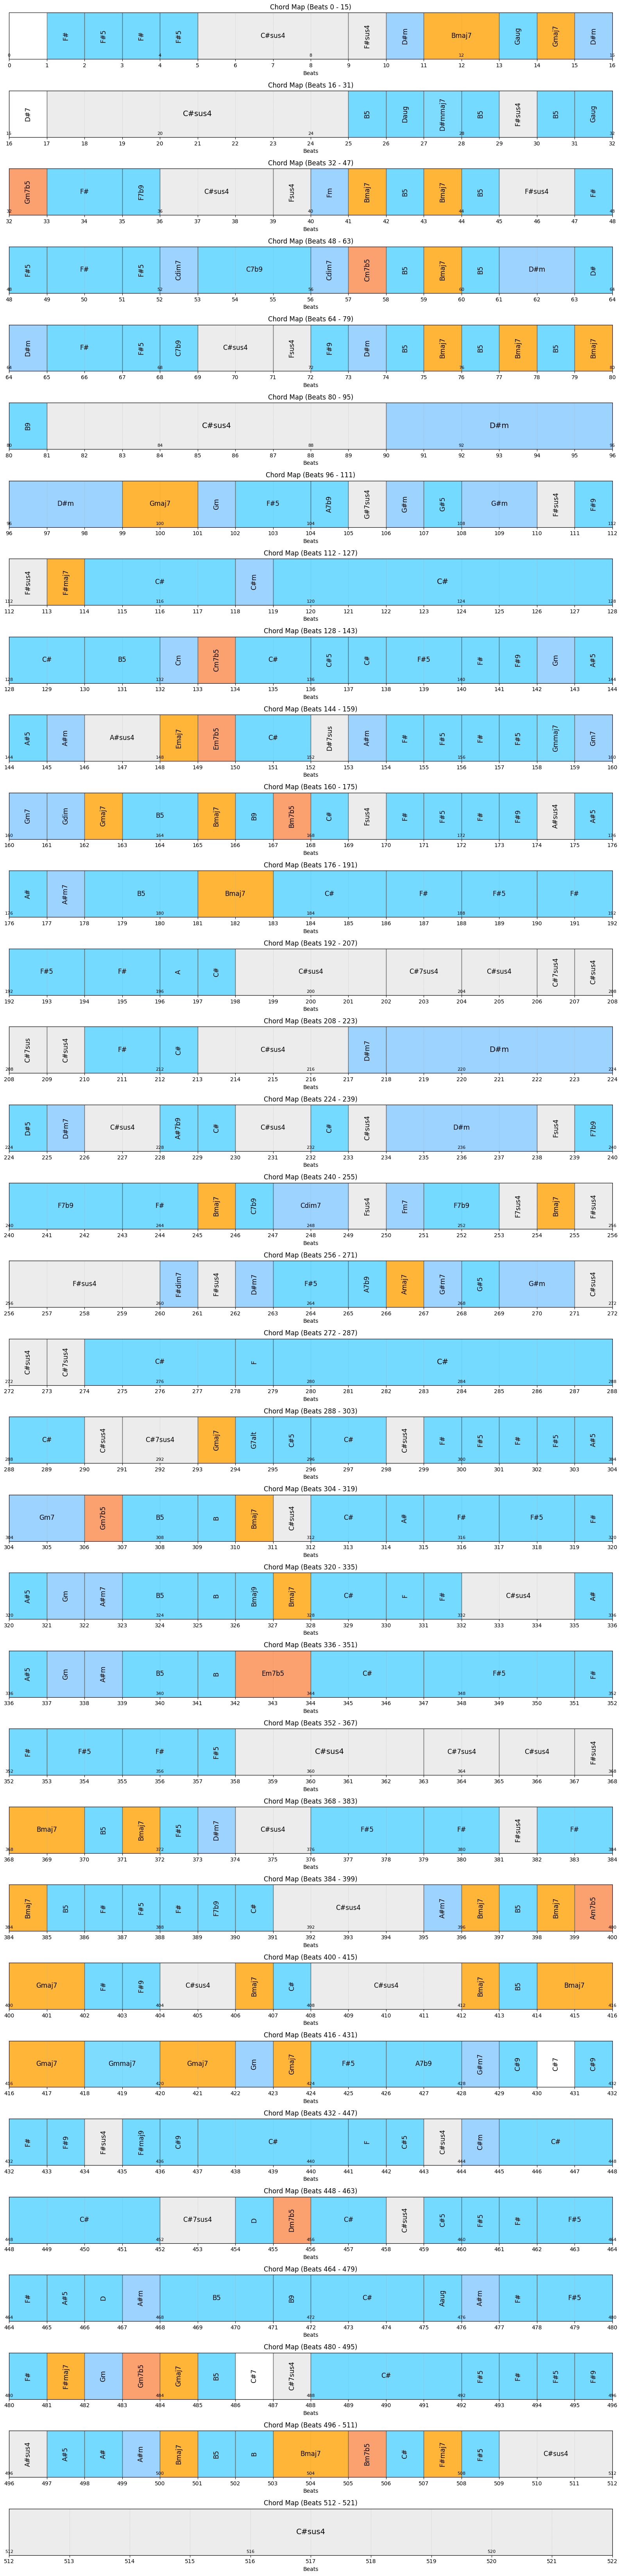

In [1]:
# Load the JSON data
import plotMe as pm
from JSON_parser import get_JSON_files

song_id = "8b8f679fcf4924e9fe048268d8fb1637"
path = "../dataset_2/lastfm/"

type = "_analysis"

song = path + song_id + "/" + song_id + type + ".json"

chords_data = get_JSON_files(song)

pm.plot_chord_score_map(chords_data, beats_per_row=16)
print("Functional harmony map plotted successfully.")
print(chords_data)

In [13]:
import json
import os

def determine_chord_type_from_intervals(intervals):
    """Determine chord type from intervals relative to the root"""
    # Convert to set for easier checking, remove 0 (root)
    interval_set = set(intervals) - {0}
    interval_list = sorted(interval_set)  # Keep sorted version for printing
    print(interval_list)
    
    if not interval_set:
        return ""  # Just root note
    
    # Power chord
    if interval_set == {7}:
        return "5"
    
    #If 4 and 5 are present, just preserve 4, but all the other intervals are preserved
    #for example {4, 5, 7} should become {4, 7} so we need to check if it contains not only ==
    if 4 in interval_set and 5 in interval_set:
        interval_set.remove(5)
        
    if 3 in interval_set and 5 in interval_set:
        interval_set.remove(5)

    # Basic triads
    if interval_set == {4, 7}:
        return ""  # Major
    if interval_set == {3, 7}:
        return "m"  # Minor
    if interval_set == {5, 7}:
        return "sus4"
    if interval_set == {2, 7}:
        return "sus2"
    if interval_set == {4, 8}:
        return "aug"
    if interval_set == {3, 6}:
        return "dim"
    
    # Seventh chords
    if interval_set == {4, 7, 11}:
        return "maj7"
    if interval_set == {4, 7, 11, 14}:
        return "maj7"
    if interval_set == {3, 4, 8, 11}:
        return "maj7"
    if interval_set == {3, 7, 10}:
        return "m7"
    if interval_set == {4, 7, 10}:
        return "7"
    if interval_set == {3, 4, 7, 11}:
        return "maj7"
    if interval_set == {3, 7, 11}:
        return "mmaj7"
    if interval_set == {3, 6, 9}:
        return "dim7"
    if interval_set == {3, 6, 10}:
        return "m7b5"
    
    # Extended chords
    if {2, 4, 7, 10} <= interval_set:
        return "9"
    if {2, 4, 7, 11} <= interval_set:
        return "maj9"
    if {2, 3, 7, 10} <= interval_set:
        return "m9"
    
    # Altered chords
    if {1, 4, 7, 10} <= interval_set:
        return "7b9"
    if {5, 7, 10} <= interval_set:
        return "7sus4"
    if {2, 7, 10} <= interval_set:
        return "7sus2"
    
    # Fall back to simpler patterns
    if 10 in interval_set:  # Has b7
        if 3 in interval_set:
            return "m7"
        elif 4 in interval_set:
            return "7"
        elif 5 in interval_set:
            return "7sus4"
    
    if 11 in interval_set:  # Has maj7
        if 3 in interval_set:
            return "mmaj7"
        elif 4 in interval_set:
            return "maj7"
    
    # Basic patterns
    if 3 in interval_set and 7 in interval_set:
        return "m"
    elif 4 in interval_set and 7 in interval_set:
        return ""
    elif 5 in interval_set and 7 in interval_set:
        return "sus4"
    elif 2 in interval_set and 7 in interval_set:
        return "sus2"
    elif 7 in interval_set:
        return "5"
    
    return ""

def relabel_chords(json_path):
    print(f"Relabeling chords in {json_path} (fixing chord types only)...")
    
    with open(json_path) as f:
        data = json.load(f)
    
    chords = data['chords'] if isinstance(data, dict) and 'chords' in data else data
    
    changes_made = 0
    
    for i, chord in enumerate(chords):
        try:
            # Get existing root information - DON'T CHANGE THIS
            root_midi = chord.get('root_midi')
            root_name = chord.get('root_name')
            notes = chord.get('notes', [])
            
            if not notes or root_midi is None:
                continue
            
            # Calculate intervals from the EXISTING root
            root_midi_int = int(root_midi)
            intervals = []
            
            for note_str in notes:
                note_midi = int(note_str)
                interval = (note_midi - root_midi_int) % 12
                intervals.append(interval)
            
            # Remove duplicates
            intervals = list(set(intervals))
            
            # Determine chord type from intervals
            chord_type = determine_chord_type_from_intervals(intervals)
            
            # Create chord name using EXISTING root
            chord_name = root_name + chord_type
            
            # Update only if different
            old_type = chord.get('chord_type', '')
            old_name = chord.get('chord_name', '')
            
            if old_type != chord_type or old_name != chord_name:
                chord['chord_type'] = chord_type
                chord['chord_name'] = chord_name
                print(f"Chord {i}: {old_name} ({old_type}) -> {chord_name} ({chord_type})")
                changes_made += 1
                    
        except Exception as e:
            print(f"Error processing chord {i}: {e}")
    
    print(f"Updated {changes_made} chords")
    
    # Save to new file
    dirname, fname = os.path.split(json_path)
    if fname.endswith('_analysis.json'):
        out_fname = fname.replace('_analysis.json', '_filtered.json')
    else:
        out_fname = fname.replace('.json', '_filtered.json')
    
    out_path = os.path.join(dirname, out_fname)
    
    # if os.path.exists(out_path):
    #     print(f"File already exists, not overwriting: {out_path}")
    #     return
    
    # Write the data back in its original structure
    if isinstance(data, dict) and 'chords' in data:
        data['chords'] = chords
        with open(out_path, 'w') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
    else:
        with open(out_path, 'w') as f:
            json.dump(chords, f, indent=2, ensure_ascii=False)
    
    print(f"Saved corrected file to {out_path}")


In [14]:
song_id = "8b8f679fcf4924e9fe048268d8fb1637"
path = "../dataset_2/lastfm/"

type = "_analysis"

song = path + song_id + "/" + song_id + type + ".json"
relabel_chords(song)

Relabeling chords in ../dataset_2/lastfm/8b8f679fcf4924e9fe048268d8fb1637/8b8f679fcf4924e9fe048268d8fb1637_analysis.json (fixing chord types only)...
[4]
[7]
[4]
[4, 7]
Chord 3: F#5 (5) -> F# ()
[5]
Chord 4: C#sus4 (sus4) -> C# ()
[5, 9]
Chord 5: F#sus4 (sus4) -> F# ()
[3, 8]
Chord 6: D#m (m) -> D# ()
[3, 4, 7, 11]
[3, 4, 8, 11]
Chord 8: Gaug (aug) -> Gmaj7 (maj7)
[3, 4, 8, 11]
[3, 7]
[7, 10]
Chord 11: D#7 (7) -> D#5 (5)
[5, 8]
Chord 12: C#sus4 (sus4) -> C# ()
[4, 7]
Chord 13: B5 (5) -> B ()
[4, 8, 9]
Chord 14: Daug (aug) -> D ()
[3, 7, 8, 11]
[4, 7]
Chord 16: B5 (5) -> B ()
[4, 5, 9]
Chord 17: F#sus4 (sus4) -> F# ()
[7]
[3, 4, 8, 11]
Chord 19: Gaug (aug) -> Gmaj7 (maj7)
[6, 11]
Chord 20: Gm7b5 (m7b5) -> G ()
[4]
[1, 8]
Chord 22: F7b9 (7b9) -> F ()
[5]
Chord 23: C#sus4 (sus4) -> C# ()
[1, 5, 8]
Chord 24: Fsus4 (sus4) -> F ()
[1, 3, 8]
Chord 25: Fm (m) -> F ()
[4, 7, 11]
[7]
[4, 7, 11]
[4, 7]
Chord 29: B5 (5) -> B ()
[4, 5]
Chord 30: F#sus4 (sus4) -> F# ()
[4, 9]
[7]
[4]
[4, 7]
Chord 34

In [21]:
import json

def compare_chord_files(path_a, path_b):
    with open(path_a) as fa, open(path_b) as fb:
        obj_a = json.load(fa)
        obj_b = json.load(fb)

    # Use 'chords' key if present, otherwise use top-level (list or dict)
    chords_a = obj_a['chords'] if 'chords' in obj_a else obj_a
    chords_b = obj_b['chords'] if 'chords' in obj_b else obj_b

    # Convert dicts to lists (sorted by int keys) for sequential comparison
    if isinstance(chords_a, dict):
        chords_a = [chords_a[k] for k in sorted(chords_a, key=int)]
    if isinstance(chords_b, dict):
        chords_b = [chords_b[k] for k in sorted(chords_b, key=int)]

    n = min(len(chords_a), len(chords_b))
    for i in range(n):
        ca, cb = chords_a[i], chords_b[i]
        diffs = {}
        for field in ['chord_name', 'chord_type']:
            if ca.get(field) != cb.get(field):
                diffs[field] = (ca.get(field), cb.get(field))
        # if diffs:
        #     print(f"Chord {i}:")
        #     for field, (old, new) in diffs.items():
        #         print(f"  {field}: {old} --> {new}")
        print(f"Chord {i}:")
        print(f"  name: {ca.get('chord_name', '')} type: {ca.get('chord_type', '')} --> name: {cb.get('chord_name', '')} type: {cb.get('chord_type', '')}")
# Usage:
compare_chord_files(
    '/workspace/dataset_2/lastfm/8b8f679fcf4924e9fe048268d8fb1637/8b8f679fcf4924e9fe048268d8fb1637_analysis.json',
    '/workspace/dataset_2/lastfm/8b8f679fcf4924e9fe048268d8fb1637/8b8f679fcf4924e9fe048268d8fb1637_filtered.json'
)


Chord 0:
  name: F# type:  --> name: F# type: 
Chord 1:
  name: F#5 type: 5 --> name: F#5 type: 5
Chord 2:
  name: F# type:  --> name: F# type: 
Chord 3:
  name: F#5 type: 5 --> name: F# type: 
Chord 4:
  name: C#sus4 type: sus4 --> name: C# type: 
Chord 5:
  name: F#sus4 type: sus4 --> name: F# type: 
Chord 6:
  name: D#m type: m --> name: D# type: 
Chord 7:
  name: Bmaj7 type: maj7 --> name: Bmaj7 type: maj7
Chord 8:
  name: Gaug type: aug --> name: Gmaj7 type: maj7
Chord 9:
  name: Gmaj7 type: maj7 --> name: Gmaj7 type: maj7
Chord 10:
  name: D#m type: m --> name: D#m type: m
Chord 11:
  name: D#7 type: 7 --> name: D#5 type: 5
Chord 12:
  name: C#sus4 type: sus4 --> name: C# type: 
Chord 13:
  name: B5 type: 5 --> name: B type: 
Chord 14:
  name: Daug type: aug --> name: D type: 
Chord 15:
  name: D#mmaj7 type: mmaj7 --> name: D#mmaj7 type: mmaj7
Chord 16:
  name: B5 type: 5 --> name: B type: 
Chord 17:
  name: F#sus4 type: sus4 --> name: F# type: 
Chord 18:
  name: B5 type: 5 --> n